# 02 · Modelado

Fase 4 de CRISP-DM. La lógica está en `src/bank_captacion/train.py` y `models.py`; este notebook presenta los resultados que generó el pipeline (`python -m bank_captacion.pipeline`). Todo se evalúa sobre el **train limpio (40.690 filas)** con la misma partición; el hold-out no se usa en esta fase.

In [1]:
import json
import pandas as pd
from IPython.display import Image, display, Markdown
from bank_captacion import config as cfg
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

def show(fig):
    display(Image(filename=str(cfg.FIGURES_DIR / fig)))

def table(name, **kw):
    df = pd.read_csv(cfg.TABLES_DIR / name, **kw)
    display(df)
    return df


## 1. Protocolo de validación

`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`: cada fold conserva la proporción de conversiones (~11,7 %). Todo el preprocesamiento (winsorización, imputación, escalado, codificación, SMOTE) está dentro del pipeline y se ajusta solo con los 4 folds de entrenamiento de cada iteración.

In [2]:
table('cv_folds.csv')

,fold,n_train,n_valid,pos_rate_train,pos_rate_valid
0,0,32552,8138,0.1172,0.1171
1,1,32552,8138,0.1172,0.1171
2,2,32552,8138,0.1172,0.1172
3,3,32552,8138,0.1172,0.1172
4,4,32552,8138,0.1172,0.1172


,fold,n_train,n_valid,pos_rate_train,pos_rate_valid
0,0,32552,8138,0.1172,0.1171
1,1,32552,8138,0.1172,0.1171
2,2,32552,8138,0.1172,0.1172
3,3,32552,8138,0.1172,0.1172
4,4,32552,8138,0.1172,0.1172


## 2. Comparación de 10 algoritmos (modelo pre-contacto, sin `duration`)

Cada modelo representa una familia distinta vista en la materia. En esta primera comparación se usan pesos de clase en los modelos que los admiten.

,model,label,family,roc_auc_fmt,pr_auc_fmt,lift@20_fmt,brier_fmt,gain@20_mean,fit_time_s_mean,predict_ms_per_1k_mean
0,lightgbm,LightGBM,Ensamble (boosting),0.8030 ± 0.0111,0.4567 ± 0.0204,3.1169 ± 0.0840,0.1458 ± 0.0040,0.6235,0.7763,10.2335
1,xgboost,XGBoost,Ensamble (boosting),0.7994 ± 0.0113,0.4541 ± 0.0211,3.0729 ± 0.0751,0.1456 ± 0.0034,0.6147,1.1487,5.9553
2,random_forest,Random Forest,Ensamble (bagging),0.7975 ± 0.0097,0.4460 ± 0.0233,3.1012 ± 0.0422,0.1135 ± 0.0030,0.6204,2.6672,16.6432
3,mlp,Red neuronal (MLP 64-32),Redes neuronales,0.7892 ± 0.0120,0.4304 ± 0.0199,3.0131 ± 0.0750,0.0833 ± 0.0017,0.6028,1.4088,4.2410
4,logreg,Regresión logística,Lineal,0.7756 ± 0.0080,0.4117 ± 0.0117,2.8527 ± 0.0895,0.1800 ± 0.0023,0.5707,0.3538,4.1473
5,knn,K vecinos más cercanos (k=51),Basado en instancias,0.7709 ± 0.0074,0.4005 ± 0.0196,2.8286 ± 0.0556,0.0853 ± 0.0016,0.5659,0.1106,45.5522
6,naive_bayes,Naive Bayes categórico,Probabilístico,0.7611 ± 0.0071,0.3953 ± 0.0191,2.7437 ± 0.1051,0.1144 ± 0.0033,0.5489,0.1239,4.2856
7,svm_rbf,SVM RBF (submuestra 10k),Márgenes / kernels,0.7742 ± 0.0068,0.3621 ± 0.0197,2.9837 ± 0.0903,NaN,0.5969,2.7325,374.2651
8,tree,Árbol de decisión (prof. 6),Árboles,0.7544 ± 0.0108,0.3510 ± 0.0196,2.7604 ± 0.1133,0.1842 ± 0.0033,0.5522,0.1890,2.9683
9,dummy,Dummy (prior),Referencia,0.5000 ± 0.0000,0.1172 ± 0.0001,0.2799 ± 0.0315,0.1034 ± 0.0001,0.0560,0.1392,3.0590


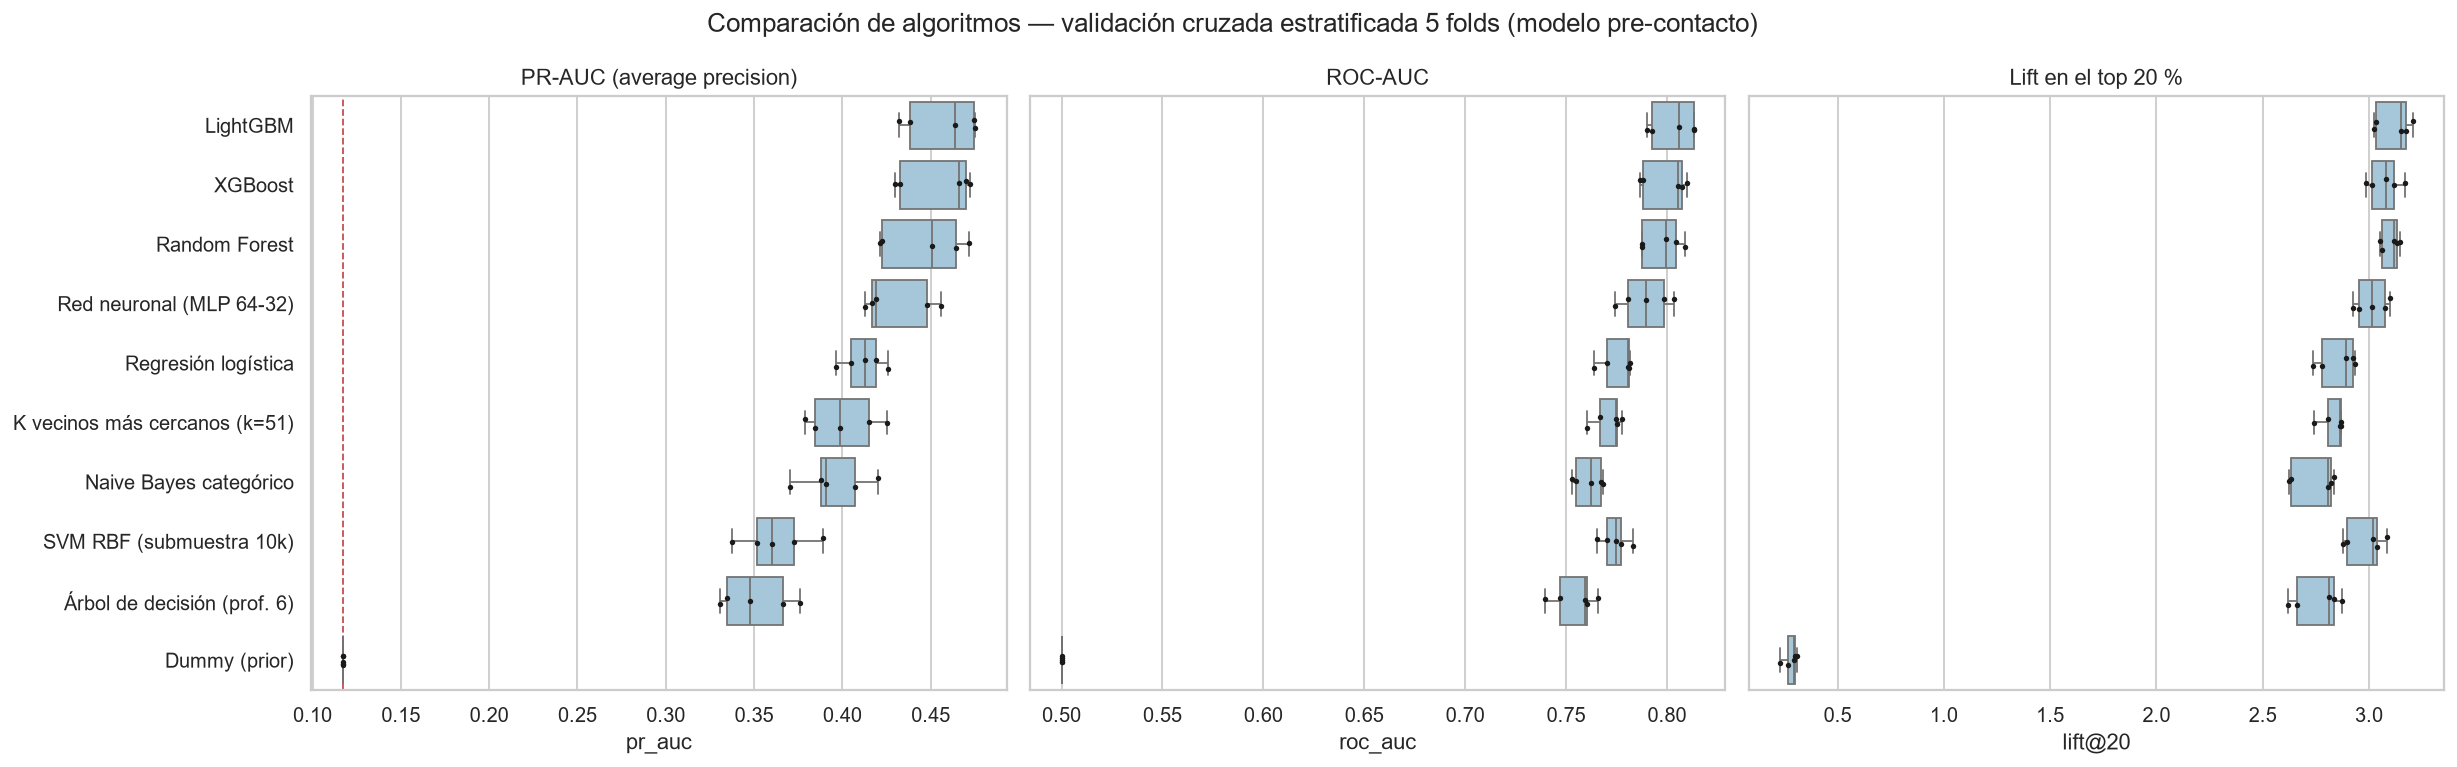

In [3]:
cv = pd.read_csv(cfg.TABLES_DIR / 'cv_results.csv')
display(cv[['model','label','family','roc_auc_fmt','pr_auc_fmt','lift@20_fmt','brier_fmt','gain@20_mean','fit_time_s_mean','predict_ms_per_1k_mean']])
show('model_cv_comparison.png')

**Lectura:**

- Los tres ensambles de árboles (LightGBM, XGBoost, Random Forest) forman el grupo superior (PR-AUC ≈ 0,45–0,46, ROC-AUC ≈ 0,80), casi 4 veces el piso del Dummy (0,117).
- La MLP queda cerca (0,43), pero sin ventaja y con menor interpretabilidad.
- La regresión logística (0,41) es el mejor modelo interpretable y el baseline de referencia: la brecha con boosting (~0,05 de PR-AUC) mide el valor de capturar no linealidades e interacciones.
- KNN y Naive Bayes rinden menos: KNN sufre con 67 dimensiones one-hot y NB con la suposición de independencia (hay variables redundantes como pdays/previous/poutcome).
- SVM RBF entrenado con 10.000 filas tiene buen ROC-AUC pero peor PR-AUC: ordena bien en general pero peor en la parte alta del ranking, que es la que importa.
- El árbol de profundidad 6 es el más débil pero es el más explicable (se usa como "reglas de negocio" en la Fase 5).

## 3. Codificación de categóricas en boosting: one-hot vs nativa

In [4]:
table('encoding_comparison.csv')[['model','kind','pr_auc_fmt','roc_auc_fmt','lift@20_fmt']]

,model,kind,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,lift@10_mean,lift@10_std,lift@20_mean,lift@20_std,lift@30_mean,lift@30_std,gain@10_mean,gain@10_std,gain@20_mean,gain@20_std,gain@30_mean,gain@30_std,brier_mean,brier_std,fit_time_s_mean,fit_time_s_std,predict_ms_per_1k_mean,predict_ms_per_1k_std,roc_auc_fmt,pr_auc_fmt,lift@20_fmt,brier_fmt
0,lightgbm,tree_onehot,0.8030,0.0111,0.4567,0.0204,4.3676,0.1716,3.1169,0.0840,2.3652,0.0503,0.4369,0.0172,0.6235,0.0168,0.7097,0.0151,0.1458,0.0040,0.7595,0.0157,9.6031,0.2944,0.8030 ± 0.0111,0.4567 ± 0.0204,3.1169 ± 0.0840,0.1458 ± 0.0040
1,lightgbm,tree_native,0.8021,0.0112,0.4580,0.0213,4.3844,0.1657,3.1064,0.0644,2.3680,0.0518,0.4385,0.0166,0.6214,0.0129,0.7106,0.0155,0.1437,0.0037,0.7460,0.0188,11.5316,0.7250,0.8021 ± 0.0112,0.4580 ± 0.0213,3.1064 ± 0.0644,0.1437 ± 0.0037
2,xgboost,tree_onehot,0.7994,0.0113,0.4541,0.0211,4.4096,0.1996,3.0729,0.0751,2.3701,0.0433,0.4411,0.0200,0.6147,0.0150,0.7112,0.0130,0.1456,0.0034,0.8744,0.0233,5.9084,0.2651,0.7994 ± 0.0113,0.4541 ± 0.0211,3.0729 ± 0.0751,0.1456 ± 0.0034
3,xgboost,tree_native,0.7978,0.0136,0.4509,0.0211,4.3970,0.1331,3.0634,0.0795,2.3631,0.0475,0.4398,0.0133,0.6128,0.0159,0.7091,0.0143,0.1415,0.0038,0.9132,0.0098,7.4861,0.3943,0.7978 ± 0.0136,0.4509 ± 0.0211,3.0634 ± 0.0795,0.1415 ± 0.0038


,model,kind,pr_auc_fmt,roc_auc_fmt,lift@20_fmt
0,lightgbm,tree_onehot,0.4567 ± 0.0204,0.8030 ± 0.0111,3.1169 ± 0.0840
1,lightgbm,tree_native,0.4580 ± 0.0213,0.8021 ± 0.0112,3.1064 ± 0.0644
2,xgboost,tree_onehot,0.4541 ± 0.0211,0.7994 ± 0.0113,3.0729 ± 0.0751
3,xgboost,tree_native,0.4509 ± 0.0211,0.7978 ± 0.0136,3.0634 ± 0.0795


En LightGBM la codificación nativa es levemente mejor (y más simple: 24 columnas en vez de 67), así que se adopta. En XGBoost el one-hot es mejor por más que la tolerancia de 0,003, así que se mantiene one-hot.

## 4. Estrategias de desbalance (sobre los 3 mejores)

(a) sin tratamiento (el umbral se ajusta después), (b) pesos de clase, (c) SMOTE dentro del pipeline (solo sobre los folds de entrenamiento).

,model,imbalance,kind,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,lift@10_mean,lift@10_std,lift@20_mean,lift@20_std,lift@30_mean,lift@30_std,gain@10_mean,gain@10_std,gain@20_mean,gain@20_std,gain@30_mean,gain@30_std,brier_mean,brier_std,fit_time_s_mean,fit_time_s_std,predict_ms_per_1k_mean,predict_ms_per_1k_std,roc_auc_fmt,pr_auc_fmt,lift@20_fmt,brier_fmt
0,lightgbm,none,tree_native,0.8038,0.0118,0.4589,0.0202,4.4158,0.2007,3.1221,0.0782,2.3806,0.0478,0.4417,0.0201,0.6246,0.0156,0.7143,0.0143,0.0810,0.0019,0.7492,0.0105,12.3480,0.8539,0.8038 ± 0.0118,0.4589 ± 0.0202,3.1221 ± 0.0782,0.0810 ± 0.0019
1,lightgbm,weights,tree_native,0.8021,0.0112,0.4580,0.0213,4.3844,0.1657,3.1064,0.0644,2.3680,0.0518,0.4385,0.0166,0.6214,0.0129,0.7106,0.0155,0.1437,0.0037,0.7407,0.0128,11.6916,0.6020,0.8021 ± 0.0112,0.4580 ± 0.0213,3.1064 ± 0.0644,0.1437 ± 0.0037
2,lightgbm,smote,tree_onehot,0.8018,0.0114,0.4552,0.0226,4.3613,0.2156,3.1054,0.0958,2.3827,0.0504,0.4362,0.0216,0.6212,0.0192,0.7150,0.0151,0.0817,0.0022,2.4239,0.0225,11.2717,0.7092,0.8018 ± 0.0114,0.4552 ± 0.0226,3.1054 ± 0.0958,0.0817 ± 0.0022
3,xgboost,none,tree_onehot,0.8024,0.0098,0.4522,0.0185,4.3760,0.1943,3.0917,0.0661,2.3715,0.0432,0.4377,0.0194,0.6185,0.0132,0.7116,0.0130,0.0817,0.0017,0.8735,0.0160,5.7476,0.4231,0.8024 ± 0.0098,0.4522 ± 0.0185,3.0917 ± 0.0661,0.0817 ± 0.0017
4,xgboost,weights,tree_onehot,0.7994,0.0113,0.4541,0.0211,4.4096,0.1996,3.0729,0.0751,2.3701,0.0433,0.4411,0.0200,0.6147,0.0150,0.7112,0.0130,0.1456,0.0034,0.9009,0.0238,5.8717,0.5540,0.7994 ± 0.0113,0.4541 ± 0.0211,3.0729 ± 0.0751,0.1456 ± 0.0034
5,xgboost,smote,tree_onehot,0.8007,0.0116,0.4514,0.0178,4.3844,0.2035,3.0991,0.0966,2.3729,0.0280,0.4385,0.0204,0.6200,0.0193,0.7120,0.0084,0.0819,0.0018,2.0509,0.0285,5.8470,0.3585,0.8007 ± 0.0116,0.4514 ± 0.0178,3.0991 ± 0.0966,0.0819 ± 0.0018
6,random_forest,none,tree_onehot,0.7991,0.0099,0.4512,0.0240,4.3215,0.1461,3.1253,0.0487,2.3617,0.0426,0.4323,0.0146,0.6252,0.0097,0.7087,0.0128,0.0816,0.0017,2.2237,0.0227,17.1389,0.5681,0.7991 ± 0.0099,0.4512 ± 0.0240,3.1253 ± 0.0487,0.0816 ± 0.0017
7,random_forest,weights,tree_onehot,0.7975,0.0097,0.4460,0.0233,4.2900,0.1564,3.1012,0.0422,2.3568,0.0496,0.4291,0.0156,0.6204,0.0084,0.7072,0.0149,0.1135,0.0030,2.4914,0.0252,16.8604,0.7992,0.7975 ± 0.0097,0.4460 ± 0.0233,3.1012 ± 0.0422,0.1135 ± 0.0030
8,random_forest,smote,tree_onehot,0.7942,0.0099,0.4359,0.0249,4.2229,0.1518,3.0739,0.0673,2.3547,0.0405,0.4224,0.0152,0.6149,0.0135,0.7066,0.0122,0.0870,0.0026,5.0978,0.0148,15.6052,0.8251,0.7942 ± 0.0099,0.4359 ± 0.0249,3.0739 ± 0.0673,0.0870 ± 0.0026


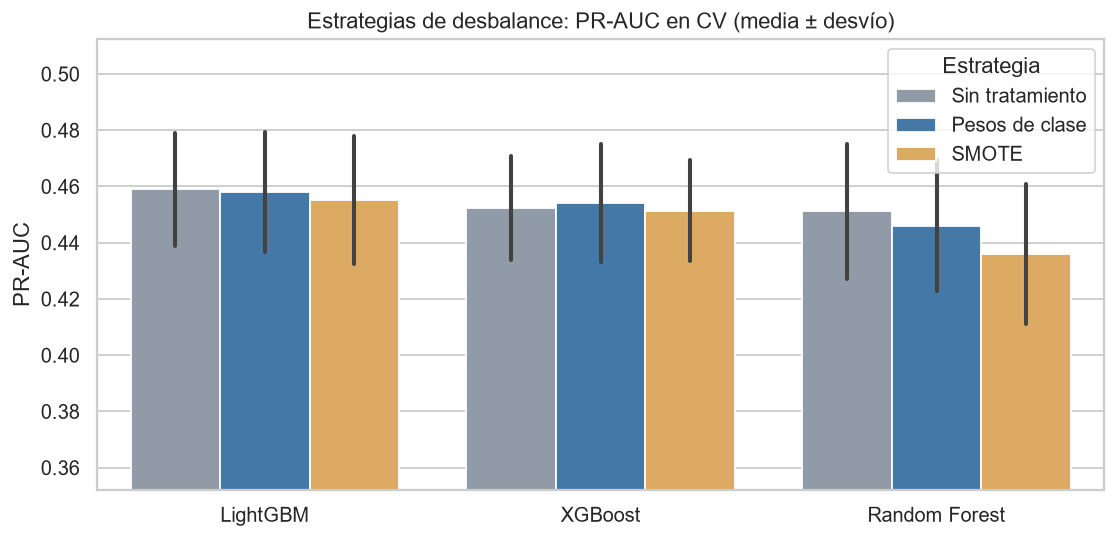

In [5]:
imb = table('imbalance_results.csv')[['model','imbalance','kind','pr_auc_fmt','roc_auc_fmt','lift@20_fmt','brier_fmt']]
show('imbalance_comparison.png')

**Resultado:** las tres estrategias quedan dentro de un desvío estándar entre sí: el desbalance (11,7 %) es moderado y los modelos de ranking no lo necesitan. Pero **pesos y SMOTE empeoran la calibración** (Brier de LightGBM: 0,081 sin tratamiento vs 0,144 con pesos), porque inflan artificialmente la probabilidad de la clase positiva. Como el umbral y el beneficio esperado se calculan con probabilidades, se elige **sin tratamiento + ajuste de umbral**. Regla aplicada: si la diferencia de PR-AUC es menor a 0,003 se prefiere la estrategia que no distorsiona las probabilidades. SMOTE además agrega costo de cómputo y genera clientes sintéticos sobre variables one-hot, que no tienen interpretación (interpolar entre "married" y "single").

## 5. Tuning con Optuna (2 mejores modelos)

Sampler TPE con semilla 42, 60 trials por modelo, tope de 15 minutos, objetivo = PR-AUC media en los mismos 5 folds.

,model,imbalance,kind,n_trials,elapsed_s,timeout_s,default_pr_auc,best_pr_auc,best_pr_auc_std,improvement,best_params
0,lightgbm,none,tree_native,60,69.4,900,0.45893,0.46604,0.02011,0.00711,"{""n_estimators"": 500, ""learning_rate"": 0.01173..."
1,xgboost,none,tree_onehot,60,71.3,900,0.45223,0.46294,0.02462,0.01071,"{""n_estimators"": 500, ""learning_rate"": 0.02297..."


lightgbm {'n_estimators': 500, 'learning_rate': 0.011735884226979234, 'num_leaves': 44, 'min_child_samples': 20, 'subsample': 0.679652764478709, 'colsample_bytree': 0.6304130496064624, 'reg_lambda': 0.002838259476758965, 'reg_alpha': 0.003913399748590477}
xgboost {'n_estimators': 500, 'learning_rate': 0.022973750787483326, 'max_depth': 8, 'min_child_weight': 30.907518053133376, 'subsample': 0.9927291835047799, 'colsample_bytree': 0.4401454361173128, 'reg_lambda': 0.11194521528130114, 'gamma': 0.003567871029203801}


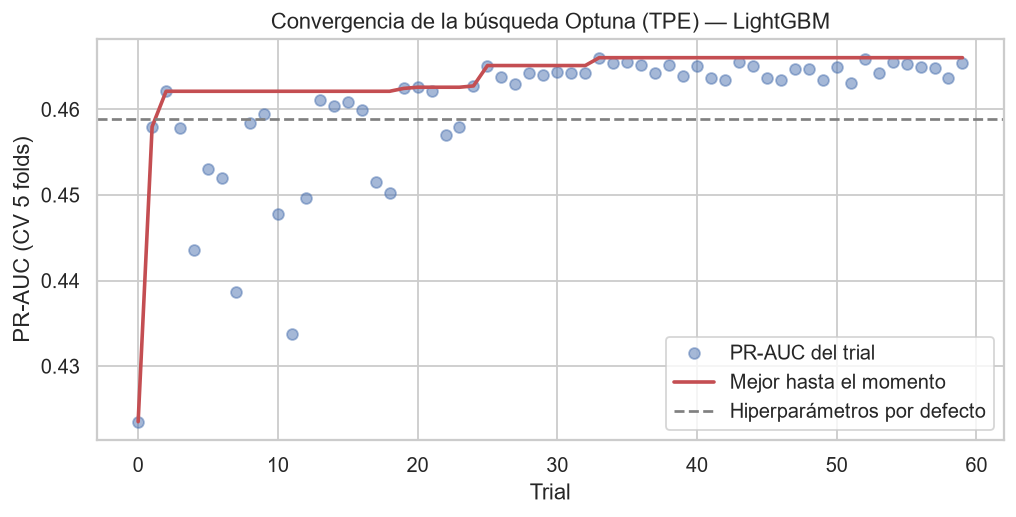

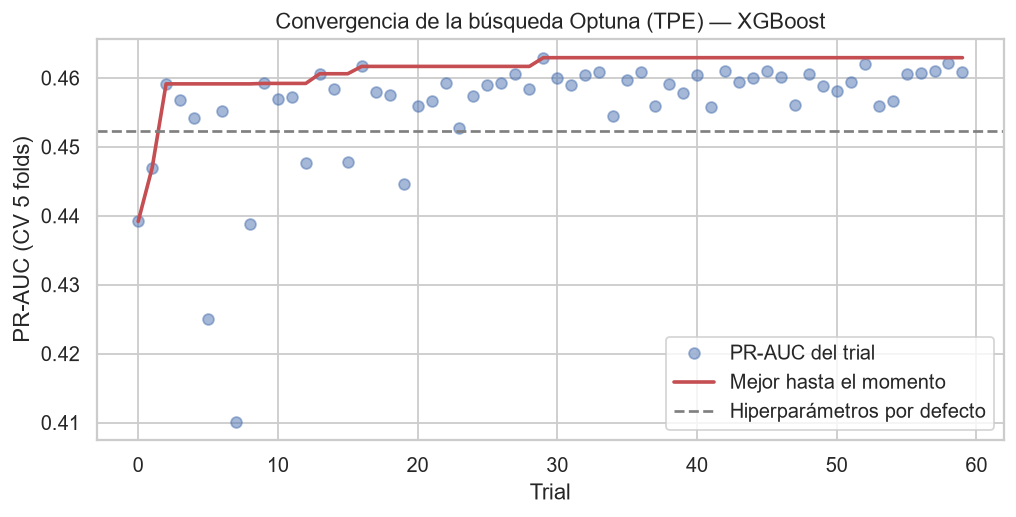

In [6]:
tun = table('tuning_summary.csv')
for _, r in tun.iterrows():
    print(r['model'], json.loads(r['best_params']))
show('tuning_convergence_lightgbm.png')
show('tuning_convergence_xgboost.png')

La mejora por tuning es chica (≈ +0,007 en LightGBM y +0,011 en XGBoost): los valores por defecto ya eran razonables y el techo lo pone la información disponible antes de llamar, no el algoritmo. Advertencia: el PR-AUC del mejor trial es optimista porque se eligió mirando esos mismos folds; la estimación sin sesgo es la del hold-out (Fase 5).

## 6. Selección final: matriz de decisión

Criterios y pesos: PR-AUC 35 %, lift@20 % 25 %, estabilidad (desvío de PR-AUC entre folds) 15 %, interpretabilidad 15 %, velocidad de inferencia 10 %. Cada criterio se normaliza 0–1 entre candidatos.

In [7]:
dm = table('decision_matrix.csv')[['candidate','pr_auc','pr_auc_std','roc_auc','lift@20','brier','predict_ms_per_1k','interpretability','weighted_score']]

,candidate,model,label,imbalance,kind,tuned,pr_auc,pr_auc_std,roc_auc,lift@20,brier,predict_ms_per_1k,interpretability,score_pr_auc,score_lift@20,score_stability,score_interpretability,score_inference_speed,weighted_score
0,lightgbm_tuned,lightgbm,LightGBM,none,tree_native,True,0.4660,0.0201,0.8060,3.1525,0.0805,15.3116,2,1.0000,1.0000,0.3492,0.25,0.0000,0.6899
1,xgboost_tuned,xgboost,XGBoost,none,tree_onehot,True,0.4629,0.0246,0.8047,3.1221,0.0810,6.9285,2,0.9429,0.8986,0.0000,0.25,0.7477,0.6669
2,xgboost_default,xgboost,XGBoost,none,tree_onehot,False,0.4522,0.0185,0.8024,3.0917,0.0817,6.3576,2,0.7457,0.7972,0.4741,0.25,0.8288,0.6518
3,lightgbm_default,lightgbm,LightGBM,none,tree_native,False,0.4589,0.0202,0.8038,3.1221,0.0810,13.1347,2,0.8691,0.8986,0.3422,0.25,0.1446,0.6321
4,logreg_default,logreg,Regresión logística,weights,linear,False,0.4117,0.0117,0.7756,2.8527,0.1800,5.3018,5,0.0000,0.0000,1.0000,1.00,1.0000,0.4000


Gana **LightGBM tuneado** (sin tratamiento de desbalance, categorías nativas): mejor PR-AUC y lift, inferencia rápida. La regresión logística es la más estable e interpretable, pero pierde ~0,05 de PR-AUC: se conserva como baseline y como contraste de explicabilidad. La falta de interpretabilidad de LightGBM se compensa con SHAP (Fase 5).

## 7. Umbral operativo

{
  "profit_threshold": 0.05,
  "profit_at_threshold": 59772.0,
  "contacted_pct_at_threshold": 61.90218726959941,
  "precision_at_threshold": 0.1686517389232968,
  "recall_at_threshold": 0.8909395973154363,
  "f1_at_threshold": 0.28361597008946454,
  "f1_threshold": 0.215,
  "f1_max": 0.4977951984321411,
  "profit_at_f1_threshold": 45363.0,
  "contacted_pct_at_f1_threshold": 13.362005406733841,
  "theoretical_threshold": 0.05,
  "profit_contact_all": 54670.0
}


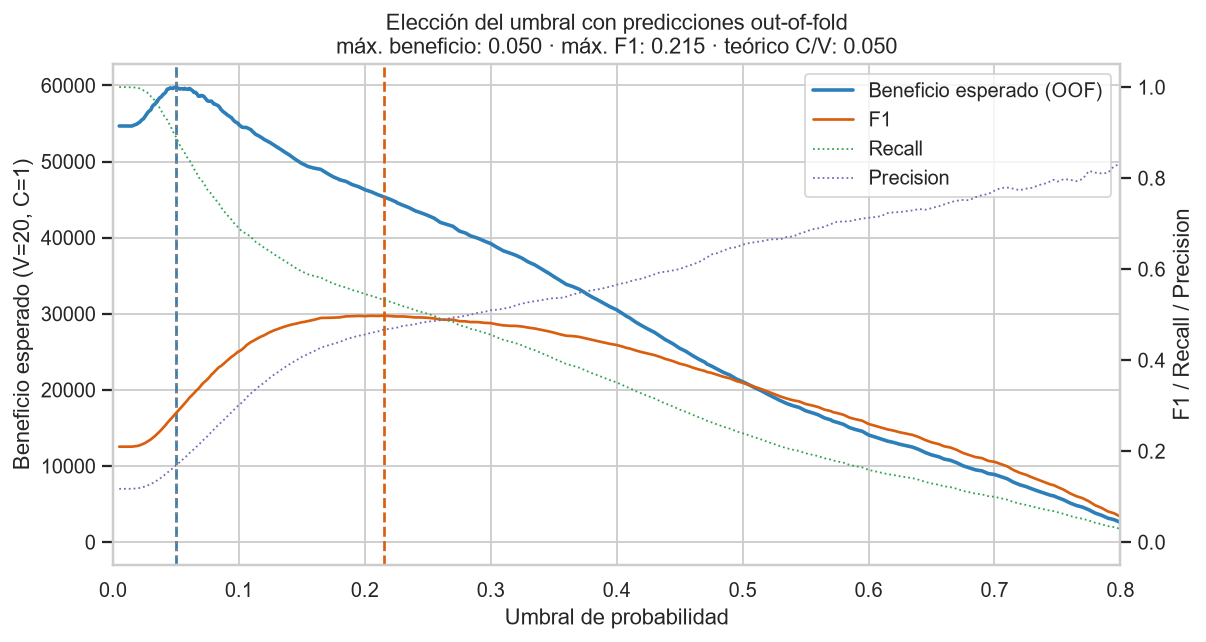

,vc_ratio,value_V,cost_C,theoretical_threshold,best_threshold,contacted_pct,recall,precision,profit_model,profit_contact_all,profit_contact_none,uplift_vs_all
0,5,5.0,1.0,0.20,0.1650,15.9449,0.5816,0.4274,7377.0,-16850.0,0.0,24227.0
1,10,10.0,1.0,0.10,0.1097,23.9936,0.6705,0.3275,22207.0,6990.0,0.0,15217.0
2,20,20.0,1.0,0.05,0.0500,61.9022,0.8909,0.1687,59772.0,54670.0,0.0,5102.0
3,50,50.0,1.0,0.02,0.0229,96.9894,0.9956,0.1203,197885.0,197710.0,0.0,175.0


,vc_ratio,value_V,cost_C,theoretical_threshold,best_threshold,contacted_pct,recall,precision,profit_model,profit_contact_all,profit_contact_none,uplift_vs_all
0,5,5.0,1.0,0.20,0.1650,15.9449,0.5816,0.4274,7377.0,-16850.0,0.0,24227.0
1,10,10.0,1.0,0.10,0.1097,23.9936,0.6705,0.3275,22207.0,6990.0,0.0,15217.0
2,20,20.0,1.0,0.05,0.0500,61.9022,0.8909,0.1687,59772.0,54670.0,0.0,5102.0
3,50,50.0,1.0,0.02,0.0229,96.9894,0.9956,0.1203,197885.0,197710.0,0.0,175.0


In [8]:
thr = json.loads((cfg.TABLES_DIR / 'threshold_choice.json').read_text())
print(json.dumps(thr, indent=2))
show('threshold_selection.png')
table('sensitivity_oof.csv')

- El umbral que **maximiza el beneficio** con V = 20 y C = 1 es **0,050**, igual al umbral teórico C/V: consistente con probabilidades bien calibradas. Contacta al ~62 % de los clientes y captura el 89 % de las conversiones.
- El umbral que **maximiza F1** es 0,215: contacta solo al ~13 % y deja muchas conversiones rentables sin llamar. F1 pondera igual precisión y recall, sin considerar que una conversión vale 20 veces lo que cuesta una llamada; por eso su beneficio es menor.
- La sensibilidad muestra que el umbral depende del ratio V/C: con V/C = 5 conviene contactar al 16 %; con V/C = 50, a casi todos.

## 8. Efecto de `duration` (leakage) en CV

In [9]:
table('leakage_cv.csv')[['feature_set','roc_auc_fmt','pr_auc_fmt','lift@20_fmt']]

,feature_set,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,lift@10_mean,lift@10_std,lift@20_mean,lift@20_std,lift@30_mean,lift@30_std,gain@10_mean,gain@10_std,gain@20_mean,gain@20_std,gain@30_mean,gain@30_std,brier_mean,brier_std,fit_time_s_mean,fit_time_s_std,predict_ms_per_1k_mean,predict_ms_per_1k_std,roc_auc_fmt,pr_auc_fmt,lift@20_fmt,brier_fmt
0,pre_contact,0.8060,0.0099,0.466,0.0201,4.4012,0.1568,3.1525,0.0704,2.3862,0.0467,0.4402,0.0157,0.6307,0.0141,0.7160,0.0140,0.0805,0.0016,0.9604,0.0409,14.4505,0.7349,0.8060 ± 0.0099,0.4660 ± 0.0201,3.1525 ± 0.0704,0.0805 ± 0.0016
1,with_duration,0.9371,0.0054,0.638,0.0290,5.4433,0.2067,4.1936,0.0650,3.1543,0.0316,0.5445,0.0207,0.8389,0.0130,0.9465,0.0095,0.0611,0.0022,1.0209,0.0353,13.8332,0.7135,0.9371 ± 0.0054,0.6380 ± 0.0290,4.1936 ± 0.0650,0.0611 ± 0.0022


,feature_set,roc_auc_fmt,pr_auc_fmt,lift@20_fmt
0,pre_contact,0.8060 ± 0.0099,0.4660 ± 0.0201,3.1525 ± 0.0704
1,with_duration,0.9371 ± 0.0054,0.6380 ± 0.0290,4.1936 ± 0.0650


Agregar `duration` sube el ROC-AUC de 0,81 a 0,94 y el PR-AUC de 0,47 a 0,64. Es una mejora **ilusoria**: esa información no existe cuando hay que decidir a quién llamar.